# 1 — Feature engineering and exploratory analysis

Raw GPS traces and parcel outlines are turned into one feature row per
agricultural intervention, and the resulting table is explored.

**On data availability.** `data/raw/trajets_train/` contains a 100-file sample
of the 500 training trajectories; the full set is not redistributed here. That
is enough to run the feature pipeline end to end, and section 3 verifies that
the pipeline reproduces the stored feature table
(`data/processed/merged_data.csv`) exactly on the overlapping rows. Modelling
in notebook 2 uses that stored table, so every published result is
reproducible from this repository.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("../src")
from data_processing import process_parcels, process_trajectories

RAW = "../data/raw"
PROCESSED = "../data/processed"
FIGURES = "../reports/figures"
os.makedirs(FIGURES, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.width", 120)

## 1. Intervention records

In [2]:
interventions = pd.read_csv(f"{RAW}/interventions_train.csv")
interventions["ID"] = interventions["ID"].astype(str)

print(f"{len(interventions)} interventions, {interventions['Parcelle'].nunique()} distinct parcels")
interventions.head()

500 interventions, 30 distinct parcels


,ID,Debut,Fin,Machine,Puissance,Outil,Largeur,Parcelle,Operation,Consommation (L)
0,284530,2024-05-07 08:40:02,2024-05-07 10:38:44,LANDINI LANDPOWER135,134,STUBBLE PLOW 16D ATMAR,2.4,54041,Travaux du sol,7.350000
1,284454,2024-05-06 13:50:23,2024-05-06 17:00:53,LANDINI LANDPOWER135,134,STUBBLE PLOW 16D ATMAR,2.4,54041,Travaux du sol,12.098333
2,283718,2024-04-30 11:20:31,2024-04-30 16:18:37,LANDINI LANDPOWER135,134,STUBBLE PLOW 16D ATMAR,2.4,54041,Travaux du sol,19.556667
3,283288,2024-04-27 10:41:04,2024-04-27 11:27:22,LANDINI LANDPOWER135,134,STUBBLE PLOW 16D ATMAR,2.4,54051,Travaux du sol,2.616667
4,282399,2024-04-21 10:23:56,2024-04-21 11:18:50,LANDINI LANDPOWER135,134,STUBBLE PLOW 16D ATMAR,2.4,54012,Travaux du sol,3.815000


In [3]:
# The target is strongly right-skewed: most jobs are short, a few are very long.
target = interventions["Consommation (L)"]
print(target.describe().round(3))

count    500.000
mean       3.532
std        4.586
min        0.006
25%        0.252
50%        1.144
75%        5.508
max       23.268
Name: Consommation (L), dtype: float64


Mean 3.53 L against a median of 1.14 L and a maximum of 23 L. That skew matters
later: a model can look accurate on average while being useless on the small
jobs that make up half the data. It is also why mean absolute error is the right
metric here and why a *baseline* is needed to interpret it.

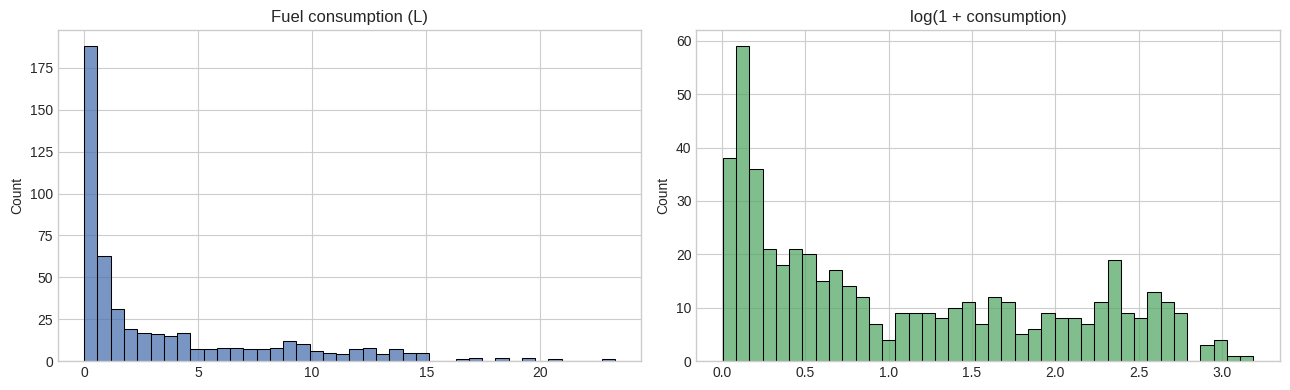

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(target, bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Fuel consumption (L)")
sns.histplot(np.log1p(target), bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("log(1 + consumption)")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig(f"{FIGURES}/target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Build features from the raw traces

`process_trajectories` reduces each GPS trace to duration, distance and
speed/acceleration summaries. `process_parcels` reprojects each parcel outline
to its local UTM zone and measures area and perimeter.

In [5]:
trajectories = process_trajectories(f"{RAW}/trajets_train")
trajectories["ID"] = trajectories["ID"].astype(str)
parcels = process_parcels(f"{RAW}/Parcelles")

print(f"trajectories processed: {len(trajectories)}")
print(f"parcels processed:      {len(parcels)}")
trajectories.head(3)

trajectories processed: 100
parcels processed:      29


,ID,Duree_mn,Distance_km,Vitesse_moy_kmph,Vitesse_med_kmph,Vitesse_max_kmph,Accélération_moy_kmph2,Accélération_max_kmph2
0,101317,55.6,6.690485,6.842011,9.0,11,-8.633094,5400.0
1,104415,290.3,44.865841,8.783058,10.0,16,-2.480193,6000.0
2,104744,208.0,30.445220,8.289284,10.0,24,0.000000,6600.0


### Coverage check

In [6]:
covered = interventions["ID"].isin(trajectories["ID"]).sum()
parcels_covered = interventions["Parcelle"].astype(str).isin(parcels["Parcelle"].astype(str)).sum()

print(f"interventions with a trajectory file in this repo: {covered} / {len(interventions)}")
print(f"interventions whose parcel outline is available:   {parcels_covered} / {len(interventions)}")
print(f"parcel outlines on disk: {len(parcels)} for {interventions['Parcelle'].nunique()} parcels referenced")

interventions with a trajectory file in this repo: 100 / 500
interventions whose parcel outline is available:   496 / 500
parcel outlines on disk: 29 for 30 parcels referenced


One parcel outline is genuinely missing from the source data, which affects 4
interventions. Those rows are median-imputed below. The trajectory shortfall is
a redistribution limit of this repository, not a property of the dataset.

## 3. Validating the stored feature table

Because the full trajectory set is not shipped, the stored table has to earn
trust. The check below recomputes features for the 100 trajectories that *are*
present and compares them against the stored values.

In [7]:
stored = pd.read_csv(f"{PROCESSED}/merged_data.csv")
stored["ID"] = stored["ID"].astype(str)

check = stored.merge(trajectories, on="ID", suffixes=("_stored", "_recomputed"))
feature_cols = ["Duree_mn", "Distance_km", "Vitesse_moy_kmph", "Vitesse_med_kmph",
                "Vitesse_max_kmph", "Accélération_moy_kmph2", "Accélération_max_kmph2"]

diffs = {c: (check[f"{c}_stored"] - check[f"{c}_recomputed"]).abs().max() for c in feature_cols}
print(f"rows compared: {len(check)}")
print(pd.Series(diffs, name="max absolute difference").to_string())
assert max(diffs.values()) < 1e-9, "pipeline no longer reproduces the stored features"
print("\nPipeline reproduces the stored table exactly.")

rows compared: 100
Duree_mn                  0.000000e+00
Distance_km               2.183498e-11
Vitesse_moy_kmph          1.776357e-15
Vitesse_med_kmph          0.000000e+00
Vitesse_max_kmph          0.000000e+00
Accélération_moy_kmph2    1.421085e-14
Accélération_max_kmph2    0.000000e+00

Pipeline reproduces the stored table exactly.


Agreement to floating-point precision (largest discrepancy ~1e-11 km, from
summation order). The pipeline in `src/data_processing.py` is the one that
produced `merged_data.csv`, so the stored table can be used downstream with
confidence.

### How the merge would run on the complete data

Kept here for reference — this is the code path that built the stored table.

In [8]:
merged_demo = (
    interventions
    .merge(trajectories, on="ID", how="left")
    .merge(parcels, on="Parcelle", how="left")
)

for col in ["Surface_ha", "Perimetre_km", "Complexite"]:
    # Assign rather than fillna(inplace=True) on a slice, which is deprecated
    # in pandas 2.x and a no-op in pandas 3.
    merged_demo[col] = merged_demo[col].fillna(merged_demo[col].median())

print("shape:", merged_demo.shape)
print(f"rows with trajectory features: {merged_demo['Duree_mn'].notna().sum()} / {len(merged_demo)}")

shape: (500, 20)
rows with trajectory features: 100 / 500


## 4. Exploratory analysis

From here on the complete 500-row stored table is used.

In [9]:
df = stored.copy()
numeric = df.select_dtypes(include=np.number)
correlations = numeric.corr()["Consommation (L)"].drop("Consommation (L)").sort_values()

print(correlations.round(3).to_string())

Largeur                  -0.663
Vitesse_moy_kmph         -0.156
Vitesse_med_kmph         -0.054
Surface_ha                0.015
Perimetre_km              0.052
Vitesse_max_kmph          0.105
Complexite                0.131
Accélération_max_kmph2    0.166
Accélération_moy_kmph2    0.250
Puissance                 0.608
Distance_km               0.935
Duree_mn                  0.951


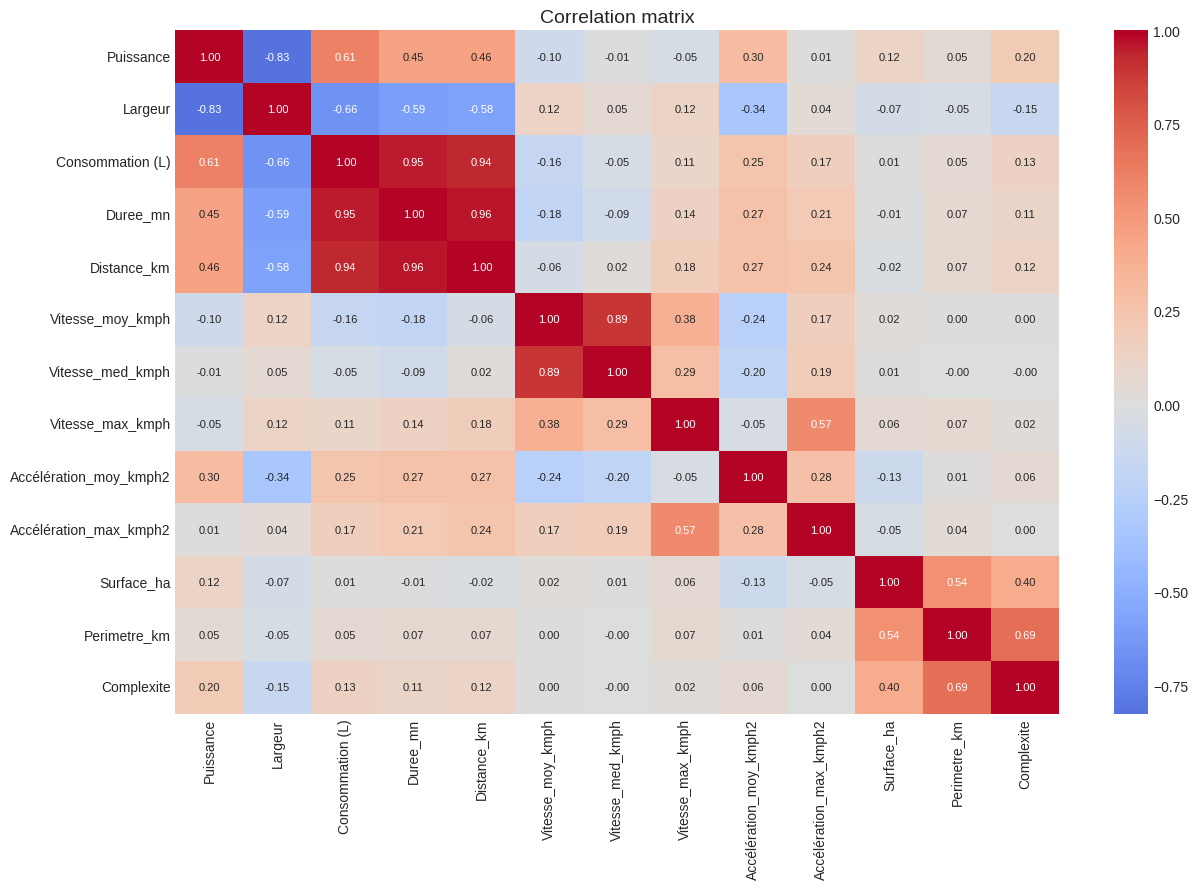

In [10]:
plt.figure(figsize=(13, 9))
sns.heatmap(numeric.drop(columns=["ID"], errors="ignore").corr(),
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 8})
plt.title("Correlation matrix", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES}/correlation_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

### Reading the correlations

- **Duration (0.95) and distance (0.94)** dominate everything else. This is
  mechanically unsurprising: both measure how much work the tractor actually
  did. It also bounds what the model can claim — see the note on framing below.
- **Engine power (0.61)** adds a genuine second axis. Bigger tractors burn more
  per unit of work.
- **Tool width (−0.66)** is negative, and it is tempting to read that as *wider
  tools are more efficient*. That reading does not survive a control.

In [11]:
# Width is not randomly assigned: it is bundled with the type of operation.
by_operation = df.groupby("Operation").agg(
    n=("Largeur", "size"),
    mean_width=("Largeur", "mean"),
    mean_duration=("Duree_mn", "mean"),
    mean_consumption=("Consommation (L)", "mean"),
).round(2).sort_values("mean_width")

print(by_operation.to_string())

                               n  mean_width  mean_duration  mean_consumption
Operation                                                                    
Semis                          3         3.4         108.00              2.45
Travaux du sol               258         3.5         118.85              6.45
Fertilisation                  6        24.0          38.05              0.66
Traitements phytosanitaires  233        24.0          24.59              0.39


In [12]:
# Within a single operation type, does width still predict consumption?
within = (
    df.groupby("Operation")[["Largeur", "Consommation (L)"]]
    .corr().unstack().iloc[:, 1].round(3)
    .rename("corr(width, consumption) within operation")
)
print(within.to_string())

Operation
Fertilisation                    NaN
Semis                         -0.688
Traitements phytosanitaires      NaN
Travaux du sol                -0.239


Width is constant within two of the four operation types (both spraying and
fertilising use a 24 m boom), so the within-group correlation is undefined
there and weak where it can be computed. Width is not an independent variable
at all in this data — it is a near-perfect proxy for *which operation this is*,
and spraying happens to be short and light while soil work is long and heavy.

The negative correlation is therefore an artefact of confounding. Width remains
a useful *predictor*; it is not a lever anyone can pull to save fuel.

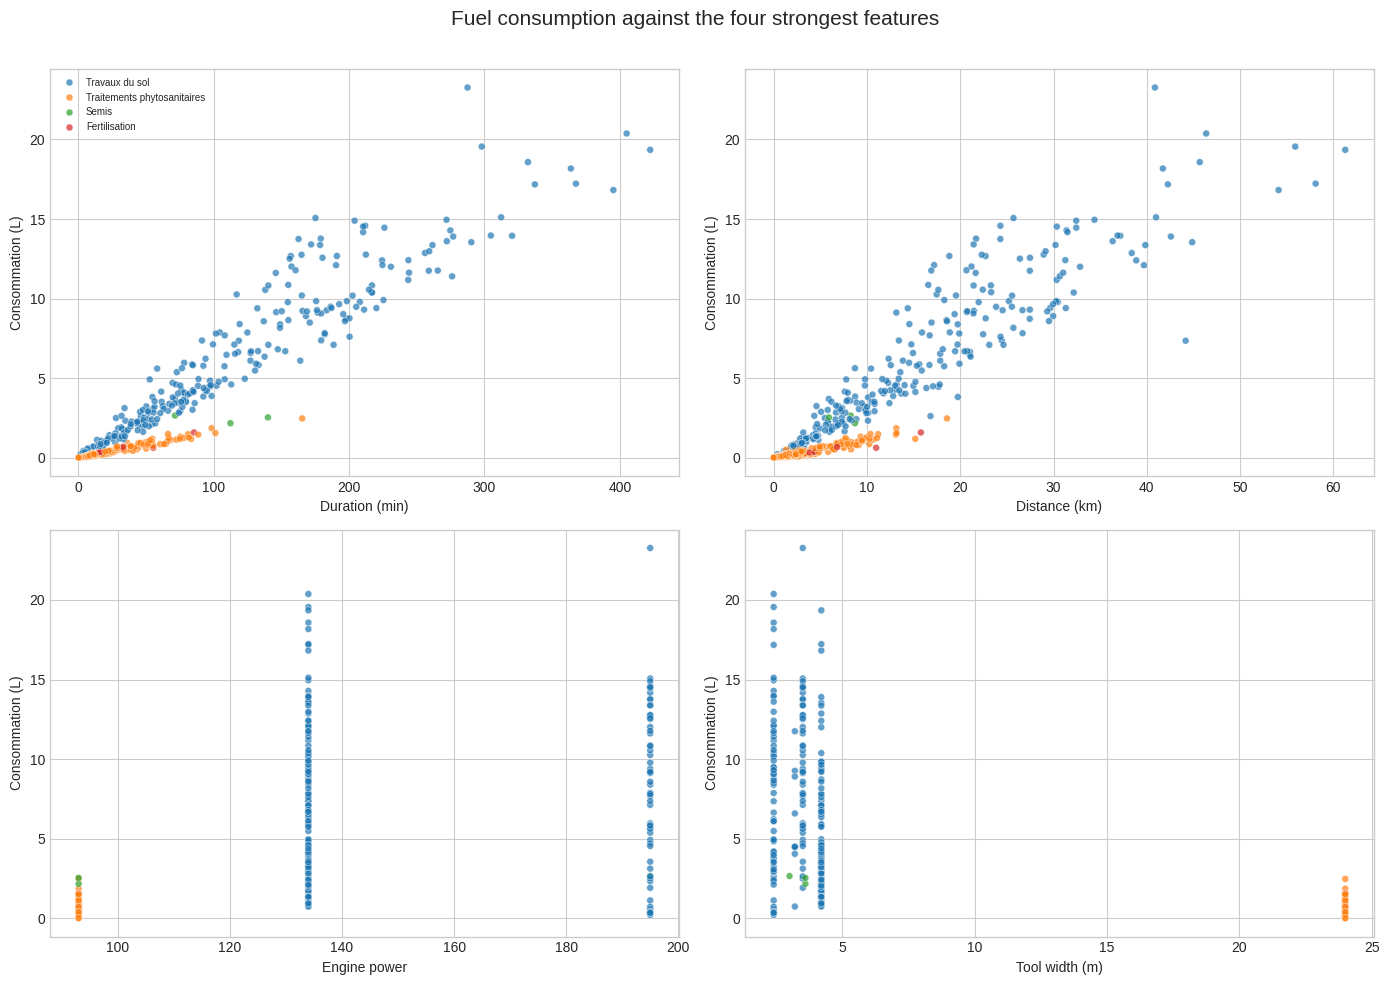

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [("Duree_mn", "Duration (min)"), ("Distance_km", "Distance (km)"),
         ("Puissance", "Engine power"), ("Largeur", "Tool width (m)")]

for ax, (col, label) in zip(axes.ravel(), pairs):
    sns.scatterplot(data=df, x=col, y="Consommation (L)", hue="Operation",
                    ax=ax, alpha=0.7, s=25, legend=(col == "Duree_mn"))
    ax.set_xlabel(label)

axes[0, 0].legend(fontsize=7, title=None)
fig.suptitle("Fuel consumption against the four strongest features", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{FIGURES}/feature_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. What this means for the modelling problem

Duration and distance are recorded *while the job runs*. That makes them
legitimate inputs for **retrospective anomaly detection** — comparing observed
consumption against what a trip of that length and shape should have used, which
is how fuel theft is detected — and illegitimate inputs for **forward planning**,
where neither value is known in advance.

This repository targets the first problem. Notebook 2 trains and evaluates on
that basis.